In [1]:
import pandas as pd
import pyreadr
import geopandas as gpd
import glob
import iris
import iris.coord_categorisation
import importlib
iris.FUTURE.date_microseconds = True

import functions
importlib.reload(functions)
from functions import *

data_dir = "/scratch/hydro4/users/kv25483/FDRI/Rain_gauge_optimisation/Data/"

In [2]:
# Load rain gauge metadata
rain_meta_cmd = pd.read_csv(data_dir + "rain_meta_for_CMD.csv")

# Convert to GeoDataFrame (BNG coordinates)
rain_meta_sf = gpd.GeoDataFrame(rain_meta_cmd, geometry=gpd.points_from_xy(rain_meta_cmd["x_2"], rain_meta_cmd["y_2"]),
                                crs="EPSG:27700")
# rain_meta_sf['station_name'].tolist()

### Get AWS rain gauge data for the Carreg and Tan gauges

In [3]:
rain_gauge = pd.read_csv(data_dir  + "RainGaugeData/Plynlimon/aws_hourly_qc.csv")
lookup = pd.read_csv(data_dir  + "RainGaugeData/Plynlimon/aws_site_metadata.csv")

carreg = rain_gauge[rain_gauge['id'].isin(['CW', 'CW2', 'CW3'])].copy()
tan = rain_gauge[rain_gauge['id'].isin(['TN', 'TN2', 'TN3', 'TW', 'TM'])].copy()

### Get NRW rain gauge data for the Dolydd and Nantgwynmain gauges

In [4]:
nrw_gauges = pyreadr.read_r(data_dir  + "RainGaugeData/NRW/NRW_rainfall_all.rds") # also works for RData
nrw_gauges = nrw_gauges[None] # extract the pandas data frame 

dolydd = nrw_gauges[nrw_gauges['station'].isin(['DOLYDD'])].copy()
nantgwynmain = nrw_gauges[nrw_gauges['station'].isin(['NANTGWYNMAIN'])].copy()

### Convert to annual values

In [60]:
def extract_annual_values (df, date_column, precip_column, source):
    # 1. Ensure datetime
    if source == 'NRW':
        df[date_column] = pd.to_datetime(df[date_column],dayfirst=True, format='mixed')
    elif source == 'ARW':
        df[date_column] = pd.to_datetime(df[date_column])
        
    # 2. Extract year
    df['year'] = df[date_column].dt.year

    # 3. Annual totals
    annual_rainfall = df.groupby('year')[precip_column].sum()
    
    # 
    annual_rainfall_df=pd.DataFrame({"rainfall":annual_rainfall})
    annual_rainfall_df.reset_index(inplace=True)

    # 4. Mean annual rainfall
    mean_annual_rainfall = annual_rainfall.mean()

    return annual_rainfall_df

# carreg_annual_means = extract_annual_values(carreg, 'date_time', 'precipitation', 'ARW')
# tan_annual_means = extract_annual_values(tan, 'date_time', 'precipitation', 'ARW')
# nantgwynmain_annual_means = extract_annual_values(nantgwynmain, 'Time stamp', 'rain_mm', 'NRW')
dolydd_annual_means = extract_annual_values(dolydd, 'Time stamp', 'rain_mm', 'NRW')

### Get equivalent rain gauge data

In [6]:
ceh_gear_dir = "/scratch/hydro4/shared_data/climate_observed/CEH-GEAR/hourly/1km/"

### Get CEH-GEAR data from 1990 to 2016

In [8]:
# Extract the single point FIRST (cheap)
DOLYDD = rain_meta_sf[rain_meta_sf['station_name']=='DOLYDD']

In [10]:
x_val = float(DOLYDD['x'].iloc[0])
y_val = float(DOLYDD['y'].iloc[0])

# Tolerance of half a grid cell (CEH-GEAR is 1km grid)
tol = 500  

x_con = iris.Constraint(projection_x_coordinate=lambda cell: abs(cell.point - x_val) < tol)
y_con = iris.Constraint(projection_y_coordinate=lambda cell: abs(cell.point - y_val) < tol)

# cubes = iris.load(filenames, x_con & y_con)
# rain_cubes = iris.cube.CubeList([c for c in cubes if c.name() == 'rainfall_amount'])
# for c in rain_cubes:
#     c.attributes = {}

# point_cube = rain_cubes.concatenate_cube()
# point_cube = point_cube.copy(data=point_cube.data)  # now tiny - will be instant

(Constraint(coord_values={'projection_x_coordinate': <function <lambda> at 0x7fcefcd38790>}),
 Constraint(coord_values={'projection_y_coordinate': <function <lambda> at 0x7fd0d01e0e50>}))

In [11]:
filenames=[]

for year in range(1990,2017):
    general_filename = ceh_gear_dir + f'CEH-GEAR-1hr-v2_{year}*'
    for filename in glob.glob(general_filename):
        filenames.append(filename)
cubes = iris.load(filenames, x_con & y_con)        

/home/kv25483/anaconda3/envs/geo_env2/lib/python3.10/site-packages/iris/__init__.py:680: FutureWarning: Ignoring a datum in netCDF load for consistency with existing behaviour. In a future version of Iris, this datum will be applied. To apply the datum when loading, use the iris.FUTURE.datum_support flag.
  cubes = _load_collection(uris, constraints, callback).combined().cubes()

KeyboardInterrupt



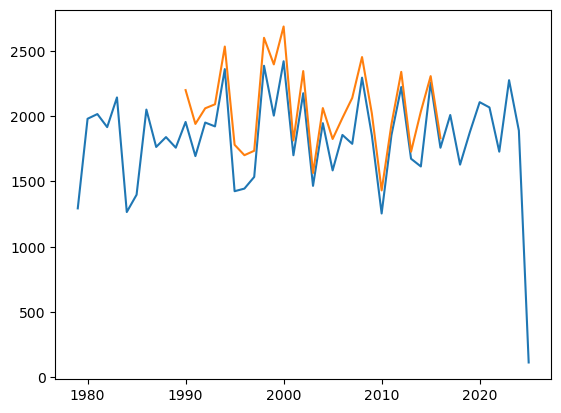

In [66]:
plt.plot(dolydd_annual_means['year'], dolydd_annual_means['rainfall'])
plt.plot(annual_total['year'], annual_total['total_rainfall_mm'])

In [35]:
import netCDF4
import numpy as np
import pandas as pd
import glob

# Find your x,y indices from the first file only
with netCDF4.Dataset(filenames[0]) as nc:
    x_coord = nc.variables['x'][:]
    y_coord = nc.variables['y'][:]
    x_idx = np.abs(x_coord - x_val).argmin()
    y_idx = np.abs(y_coord - y_val).argmin()

# Read just that pixel from every file
all_data = []
all_times = []

for f in sorted(filenames):
    with netCDF4.Dataset(f) as nc:
        data = nc.variables['rainfall_amount'][:, y_idx, x_idx]  # (time,)
        data = np.where(data == -999.0, np.nan, data)
        data = np.where(data == -9999, np.nan, data)
        data = np.where(data < 0, np.nan, data)
        
        times = netCDF4.num2date(nc.variables['time'][:], nc.variables['time'].units)
        all_data.append(data)
        all_times.extend(times)

# Combine
rainfall = np.concatenate(all_data)
times = np.array(all_times)

# Build dataframe and aggregate
df = pd.DataFrame({ 'time': times, 'rainfall': rainfall})
df['date'] = pd.to_datetime([t.strftime('%Y-%m-%d %H:%M:%S') for t in df['time']])
df['year'] = df['date'].dt.year
df['date_only'] = df['date'].dt.date

# Daily totals, then annual mean daily
annual_hourly_mean = df.groupby('year')['rainfall'].mean().reset_index()
annual_hourly_mean.columns = ['year', 'mean_daily_rainfall_mm']
annual_daily_mean = daily_totals.groupby('year')['rainfall'].mean().reset_index()
annual_daily_mean.columns = ['year', 'mean_hourly_rainfall_mm']

annual_total = df.groupby('year')['rainfall'].sum().reset_index()
annual_total.columns = ['year', 'total_rainfall_mm']

    year  mean_daily_rainfall_mm
0   1990                0.251383
1   1991                0.221518
2   1992                0.234529
3   1993                0.238687
4   1994                0.289178
5   1995                0.203253
6   1996                0.193636
7   1997                0.198037
8   1998                0.296838
9   1999                0.273584
10  2000                0.305897
11  2001                0.207043
12  2002                0.267728
13  2003                0.178596
14  2004                0.234734
15  2005                0.208345
16  2006                0.226724
17  2007                0.244269
18  2008                0.279235
19  2009                0.230719
20  2010                0.163368
21  2011                0.221153
22  2012                0.266302
23  2013                0.197180
24  2014                0.232386
25  2015                0.263322
26  2016                0.208481


In [7]:


monthly_cubes_list = iris.load(filenames)

rain_cubes = [c for c in monthly_cubes_list if c.name() == 'rainfall_amount']
rain_cubes = iris.cube.CubeList(rain_cubes)
obs_cube = rain_cubes[0]

cubes = iris.load(filenames)

rain_cubes = iris.cube.CubeList([c for c in cubes if c.name() == 'rainfall_amount'])

for c in rain_cubes:
    c.attributes = {}   # 🔥 remove all conflicting attributes

ceh_gear = rain_cubes.concatenate_cube()

catchment = gpd.read_file(data_dir + "54080/54080.shp")
ceh_gear_trimmed = trim_to_bbox_of_region_obs(ceh_gear, catchment, 'projection_y_coordinate', 'projection_x_coordinate', 1)

point_cube = ceh_gear_trimmed[:, y_idx, x_idx]
# Force realisation of JUST this point's data NOW
# while the lazy graph is still intact
point_cube = point_cube.copy(data=point_cube.data)  # .data triggers compute

/home/kv25483/anaconda3/envs/geo_env2/lib/python3.10/site-packages/iris/__init__.py:680: FutureWarning: Ignoring a datum in netCDF load for consistency with existing behaviour. In a future version of Iris, this datum will be applied. To apply the datum when loading, use the iris.FUTURE.datum_support flag.
  cubes = _load_collection(uris, constraints, callback).combined().cubes()


In [25]:
catchment = gpd.read_file(data_dir + "54080/54080.shp")
ceh_gear_trimmed = trim_to_bbox_of_region_obs(ceh_gear, catchment, 'projection_y_coordinate', 'projection_x_coordinate', 1)

In [ ]:
point_cube = ceh_gear_trimmed[:, y_idx, x_idx]
point_cube = point_cube.copy(data=point_cube.data)  # .data triggers compute

In [27]:
point_cube = ceh_gear_trimmed[:, y_idx, x_idx]
# Force realisation of JUST this point's data NOW
# while the lazy graph is still intact
point_cube = point_cube.copy(data=point_cube.data)  # .data triggers compute

del ceh_gear_trimmed
gc.collect()


KeyboardInterrupt



In [14]:
# Slice spatially BEFORE any aggregated_by call
point_cube = ceh_gear_trimmed[:, y_idx, x_idx]


# Now delete the big cube immediately
del ceh_gear_trimmed
import gc; gc.collect()
gc.collect()

# Then aggregate the tiny 1D cube
iris.coord_categorisation.add_day_of_year(point_cube, 'time', name='day_of_year')

iris.coord_categorisation.add_year(point_cube, 'time', name='year_num')
daily_total = point_cube.aggregated_by(['year_num', 'day_of_year'], iris.analysis.SUM)

iris.coord_categorisation.add_season_year(daily_total, 'time', name='year')
annual_mean_daily = daily_total.aggregated_by(['year'], iris.analysis.MEAN)

In [18]:
iris.coord_categorisation.add_year(point_cube, 'time', name='year_num')
daily_total = point_cube.aggregated_by(['year_num', 'day_of_year'], iris.analysis.SUM)

In [20]:
iris.coord_categorisation.add_season_year(daily_total, 'time', name='year')
annual_mean_daily = daily_total.aggregated_by(['year'], iris.analysis.MEAN)

In [23]:
import iris.quickplot as qplt
qplt.plot(annual_mean_daily, label="E1 scenario", lw=1.5, color="blue")


KeyboardInterrupt



### Testing new way

In [10]:
# Extract the single point FIRST (cheap)
DOLYDD = rain_meta_sf[rain_meta_sf['station_name']=='DOLYDD']
x = float(DOLYDD['x'].iloc[0])
y = float(DOLYDD['y'].iloc[0])

x_coord = ceh_gear_trimmed.coord('projection_x_coordinate').points
y_coord = ceh_gear_trimmed.coord('projection_y_coordinate').points
x_idx = np.abs(x_coord - x).argmin()
y_idx = np.abs(y_coord - y).argmin()

point_cube = ceh_gear_trimmed[:, y_idx, x_idx]  # now (time,) only

# Step 1: Sum hourly -> daily totals on the tiny 1D cube
iris.coord_categorisation.add_day_of_year(point_cube, 'time', name='day_of_year')
iris.coord_categorisation.add_year(point_cube, 'time', name='year_num')
daily_total = point_cube.aggregated_by(['year_num', 'day_of_year'], iris.analysis.SUM)

# # Step 2: Average daily totals across years
# iris.coord_categorisation.add_season_year(daily_total, 'time', name='year')
# annual_mean_daily = daily_total.aggregated_by(['year'], iris.analysis.MEAN)

# ts = annual_mean_daily.data

KeyboardInterrupt: 

### Find the annual mean

In [ ]:
iris.coord_categorisation.add_season_year(ceh_gear_trimmed, 'time', name='year')
annual_mean = ceh_gear_trimmed.aggregated_by(["year"], iris.analysis.MEAN)

In [ ]:
# Extract the single point FIRST (cheap)
x = float(DOLYDD['x'].iloc[0])
y = float(DOLYDD['y'].iloc[0])

x_coord = ceh_gear_trimmed.coord('projection_x_coordinate').points
y_coord = ceh_gear_trimmed.coord('projection_y_coordinate').points
x_idx = np.abs(x_coord - x).argmin()
y_idx = np.abs(y_coord - y).argmin()

point_cube = ceh_gear_trimmed[:, y_idx, x_idx]  # now (time,) only

# Step 1: Sum hourly -> daily totals on the tiny 1D cube
iris.coord_categorisation.add_day_of_year(point_cube, 'time', name='day_of_year')
iris.coord_categorisation.add_year(point_cube, 'time', name='year_num')
daily_total = point_cube.aggregated_by(['year_num', 'day_of_year'], iris.analysis.SUM)

# Step 2: Average daily totals across years
# iris.coord_categorisation.add_season_year(daily_total, 'time', name='year')
annual_mean_daily = daily_total.aggregated_by(['year'], iris.analysis.MEAN)

ts = annual_mean_daily.data

In [ ]:
annual_mean_daily = daily_total.aggregated_by(['year'], iris.analysis.MEAN)
ts = annual_mean_daily.data

### Plot the annual mean from Gridded data for each gauge station

In [13]:
NANTG = rain_meta_sf[rain_meta_sf['station_name']=='NANTGWYNMAIN']
NANTG.reset_index(inplace=True, drop=True)
x = float(NANTG['x'][0])
y = float(NANTG['y'][0])

x_coord = annual_mean.coord('projection_x_coordinate').points
y_coord = annual_mean.coord('projection_y_coordinate').points

# Find nearest indices
x_idx = np.argmin(np.abs(x_coord - x))
y_idx = np.argmin(np.abs(y_coord - y))

# # Slice directly — near-instant
# NANTG_annual_mean_data = annual_mean.data[:, y_idx, x_idx]  # shape (21,)
# years = annual_mean.coord('year').points

In [ ]:
annual_mean[:, y_idx, x_idx].data

In [16]:
DOLYDD = rain_meta_sf[rain_meta_sf['station_name']=='DOLYDD']
x = float(DOLYDD['x'][0])
y = float(DOLYDD['y'][0])

dolydd_annual_mean_gridded = annual_mean.interpolate([('projection_x_coordinate', x),('projection_y_coordinate', y)],
                                             iris.analysis.Nearest())

dolydd_annual_mean_gridded_data = dolydd_annual_mean_gridded.data  # should now be 1D (n_years,)
years = dolydd_annual_mean_gridded.coord('year').points

plt.scatter(years, dolydd_annual_mean_gridded_data)

NameError: name 'annual_mean' is not defined